<a href="https://colab.research.google.com/github/GuiOlympio/Classificacao-de-videira/blob/main/TensorFlow%26Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
url = '/content/drive/MyDrive/Aulas tensorFlow & Keras/uvas'

In [ ]:
import pathlib

In [ ]:
data_dir = pathlib.Path(url)

In [ ]:
# Conta a quantidade total de imagens com extensão .JPG
#localizadas dentro das subpastas de data_dir
len(list(data_dir.glob('*/*.JPG')))

1600

In [ ]:
# Cria uma lista com o nome de todas as subpastas contidas no diretório principal
subfolders = [f.name for f in data_dir.iterdir() if f.is_dir()]
subfolders

['LeafBlight', 'BlackRot', 'BlackMeasles', 'HealthyGrapes']

In [ ]:
import PIL

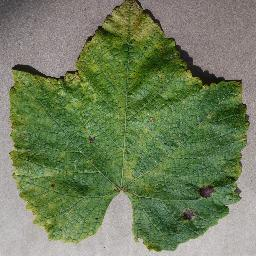

In [ ]:
# Obtém a lista de caminhos de todos os arquivos dentro da subpasta 'LeafBlight'
Leafblight = list(data_dir.glob('LeafBlight/*'))

# Abre a primeira imagem da lista para exibição e verificação visual
PIL.Image.open(str(Leafblight[0]))

In [ ]:
import numpy as np

In [ ]:
# Percorre cada subpasta encontrada anteriormente
for subfolder in subfolders:
    # Monta o caminho completo para a subpasta
    path = data_dir / subfolder

    # Lista todos os arquivos presentes dentro da subpasta
    images = list(path.glob('*'))
    print(f'For {subfolder} temos {len(images)} imagens')

    # Verifica se a pasta não está vazia
    if images:
        # Abre a primeira imagem e a converte para uma matriz NumPy
        img = PIL.Image.open(str(images[0]))
        img_array = np.array(img)

        # Exibe o formato/dimensões da imagem (Ex: Altura, Largura, Canais de cor)
        print(f'Dimensões da primeira imagem em {subfolder}: {img_array.shape}')
    else:
        print(f'Nenhuma imagem encontrada em {subfolder}')

For LeafBlight temos 400 imagens
Dimensões da primeira imagem em LeafBlight: (256, 256, 3)
For BlackRot temos 400 imagens
Dimensões da primeira imagem em BlackRot: (256, 256, 3)
For BlackMeasles temos 400 imagens
Dimensões da primeira imagem em BlackMeasles: (256, 256, 3)
For HealthyGrapes temos 400 imagens
Dimensões da primeira imagem em HealthyGrapes: (256, 256, 3)


In [ ]:
import tensorflow as tf

In [ ]:
# Define a quantidade de imagens que a rede neural processará de uma só vez por passo de treinamento
batch_size = 16

# Define a altura padrão (em pixels) para a qual todas as imagens serão redimensionadas
altura = 256

# Define a largura padrão (em pixels) para a qual todas as imagens serão redimensionadas
largura = 256

In [ ]:
# Carrega e prepara o conjunto de dados de TREINAMENTO a partir das pastas
treino = tf.keras.utils.image_dataset_from_directory(
    data_dir,                        # Diretório raiz com as subpastas das classes
    validation_split=0.2,            # Reserva 20% das imagens para validação (e mantendo 80% para treino)
    subset='training',               # Especifica que este objeto guardará o lote de TREINO
    seed=123,                        # Semente aleatória para garantir a mesma divisão sempre que rodar
    image_size=(altura, largura),    # Redimensiona automaticamente todas as imagens para 256x256 pixels
    batch_size=batch_size            # Agrupa as imagens nos lotes configurados (no seu caso, de 64 em 64)
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.


In [ ]:
# Carrega e prepara o conjunto de dados de VALIDAÇÃO a partir das pastas
validacao = tf.keras.utils.image_dataset_from_directory(
    data_dir,                        # Diretório raiz com as subpastas das classes
    validation_split=0.2,            # Reserva 20% das imagens para validação
    subset='validation',             # Especifica que este objeto guardará o lote de VALIDAÇÃO
    seed=123,                        # DEVE ser igual à semente do treino para não embaralhar errado
    image_size=(altura, largura),    # Redimensiona as imagens para 256x256 pixels
    batch_size=batch_size            # Agrupa as imagens nos lotes configurados (64)
)

Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [ ]:
# Define uma semente (seed) fixa para os geradores de números aleatórios do TensorFlow,
# garantindo que os resultados do modelo sejam exatamente os mesmos toda vez que rodar.
tf.random.set_seed(424242)

A camada Rescaling vai reescalar os valores de entrada para um novo intervalo.

In [ ]:
# Cria a estrutura do modelo sequencial (camada por camada, em fila)
modelo = tf.keras.models.Sequential([
    # Define o formato de entrada: Imagens de 256x256 pixels com 3 canais de cor (RGB)
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Normaliza os valores dos pixels de [0, 255] para a escala de [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),

    # Achata a imagem 3D (256x256x3) em um único vetor 1D de 196.608 números
    tf.keras.layers.Flatten(),

    # Camada oculta densa (totalmente conectada) com 128 neurônios e ativação ReLU
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    # Camada de saída com 4 neurônios (um para cada classe) e Softmax para retornar probabilidades
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

- **ReLU**, que significa Unidade Linear Retificada, é uma das funções de ativação mais simples e amplamente usadas em redes neurais profundas. Sua fórmula é bastante direta: se a entrada é positiva, a função retorna o valor; se é negativa, retorna zero.

- **Softmax** é outra função de ativação, mas com um propósito diferente. Enquanto ReLU é ótima para camadas ocultas, Softmax é usada na camada de saída de modelos de classificação, onde precisamos de probabilidades para cada classe.



In [ ]:
# Compila o modelo configurando o algoritmo de otimização, a função de perda e a métrica de avaliação
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),        # Otimizador Adam: ajusta os pesos dos neurônios de forma adaptativa e eficiente
    loss = 'sparse_categorical_crossentropy',       # Função de perda para classificação multiclasse com rótulos inteiros (0, 1, 2, 3)
    metrics = ['accuracy']                          # Métrica para monitorar a porcentagem de acertos durante o treino
)

In [ ]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
# Define a quantidade de vezes que o modelo vai passar por todo o dataset de treino
epocas = 10

# Treina o modelo com os dados de treino e avalia a cada época com os dados de validação
history = modelo.fit(
    treino,                     # Dados de treinamento
    validation_data = validacao,# Dados de validação para medir o desempenho sem viés
    epochs = epocas             # Número total de épocas
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.4508 - loss: 20.2323 - val_accuracy: 0.6219 - val_loss: 2.4421
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5922 - loss: 4.1623 - val_accuracy: 0.5906 - val_loss: 3.4466
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6313 - loss: 3.4548 - val_accuracy: 0.5437 - val_loss: 5.6687
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6445 - loss: 4.2852 - val_accuracy: 0.5562 - val_loss: 6.5378
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7008 - loss: 2.9920 - val_accuracy: 0.7781 - val_loss: 1.6047
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7617 - loss: 1.7256 - val_accuracy: 0.7437 - val_loss: 1.5886
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7461 - loss: 1.7576 - val_accuracy: 0.6875 - val_loss: 2.2935
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7711 - loss: 1.5598 - val_accuracy: 0.6781 - 

In [ ]:
# Exibe o resumo da arquitetura do modelo (camadas, formatos das saídas e total de parâmetros)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,499,406 (288.01 MB)

 Trainable params: 25,166,468 (96.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,332,938 (192.00 MB)

Função para dar uma atenção nos valores de acruacy e loss

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Define uma função para plotar os gráficos de Acurácia e Perda (Loss) do treinamento
def plota_resultado(history, epocas):
    # Extrai o histórico de acurácia de treino e validação
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    # Extrai o histórico de perda (loss) de treino e validação
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Cria o intervalo do eixo X correspondente às épocas (ex: 0 a 9)
    intervalo_epocas = range(epocas)

    # Configura o tamanho da figura do gráfico (largura: 12, altura: 6)
    plt.figure(figsize=(12, 6))

    # Subplot 1: Gráfico de Acurácia (lado esquerdo)
    plt.subplot(1, 2, 1)
    plt.plot(intervalo_epocas, acc, 'r', label='Acuracia de Treino')
    plt.plot(intervalo_epocas, val_acc, 'b', label='Acruacia de Validação')
    plt.legend(loc='lower right')

    # Subplot 2: Gráfico de Perda (lado direito)
    plt.subplot(1, 2, 2)
    plt.plot(intervalo_epocas, loss, 'r', label='perda de Treino')
    plt.plot(intervalo_epocas, val_loss, 'b', label='perda de Validação')
    plt.legend(loc='upper right')

    # Exibe a figura com os dois gráficos na tela
    plt.show()

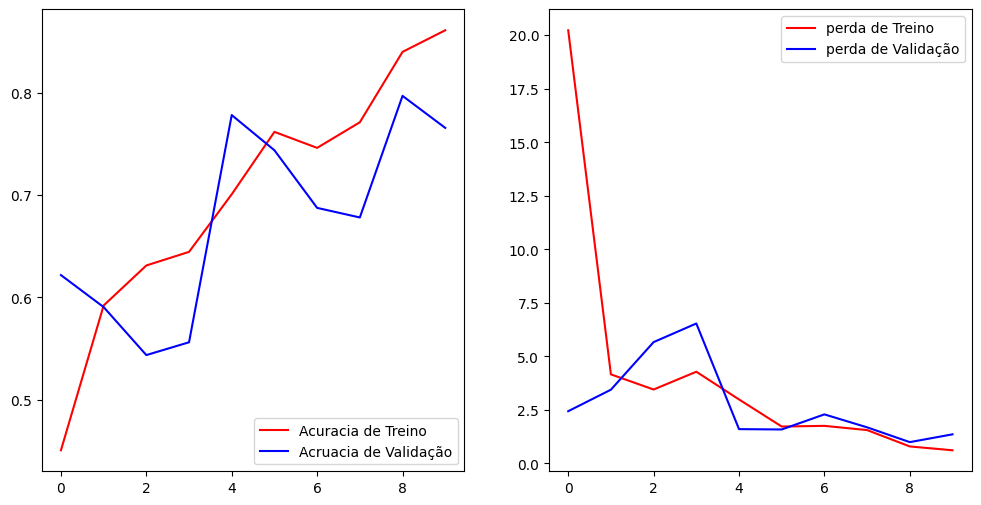

In [ ]:
# Chama a função para gerar e exibir os gráficos de desempenho (acurácia e perda)
plota_resultado(history, epocas)

- A camada **Conv2D** é responsável por passar um filtro pela imagem para enfatizar algumas características, enquanto a camada **MaxPooling2D** é responsável por reduzir a dimensionalidade da imagem.

In [ ]:
# Reinia e redefine a arquitetura do modelo, agora utilizando uma Rede Neural Convolucional (CNN)
modelo = tf.keras.models.Sequential([
    # Define o formato de entrada da imagem (256x256 pixels com 3 canais de cor)
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Normaliza os pixels para a escala de [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),

    # Camada Convolucional: Extrai características visuais (bordas, texturas, formas) usando 32 filtros de 3x3
    tf.keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu),

    # Camada de Max Pooling: Reduz a dimensão da imagem pela metade mantendo apenas os traços mais marcantes
    tf.keras.layers.MaxPooling2D(2,2),

    # Achata os mapas de características em um único vetor 1D
    tf.keras.layers.Flatten(),

    # Camada oculta densa para interpretar as características extraídas
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    # Camada de saída para as 4 classes com probabilidades (Softmax)
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

In [ ]:
# Recompila o novo modelo (CNN) configurando o otimizador, a função de perda e a métrica
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),        # Otimizador Adam para ajuste adaptativo dos pesos
    loss = 'sparse_categorical_crossentropy',       # Função de perda para classificação multiclasse com rótulos inteiros
    metrics = ['accuracy']                          # Métrica para acompanhar a acurácia
)

In [ ]:
# Re-treina o novo modelo (CNN) com as mesmas 10 épocas
history = modelo.fit(
    treino,                     # Dados de treinamento
    validation_data = validacao,# Dados de validação
    epochs = epocas             # Número total de épocas (10)
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6156 - loss: 6.6862 - val_accuracy: 0.8750 - val_loss: 0.3493
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9070 - loss: 0.2670 - val_accuracy: 0.8906 - val_loss: 0.3283
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9703 - loss: 0.1198 - val_accuracy: 0.9156 - val_loss: 0.2090
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9945 - loss: 0.0418 - val_accuracy: 0.9250 - val_loss: 0.2015
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9969 - loss: 0.0238 - val_accuracy: 0.9375 - val_loss: 0.1763
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 0.9281 - val_loss: 0.1532
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9375 - val_loss: 0.1519
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9344 - v

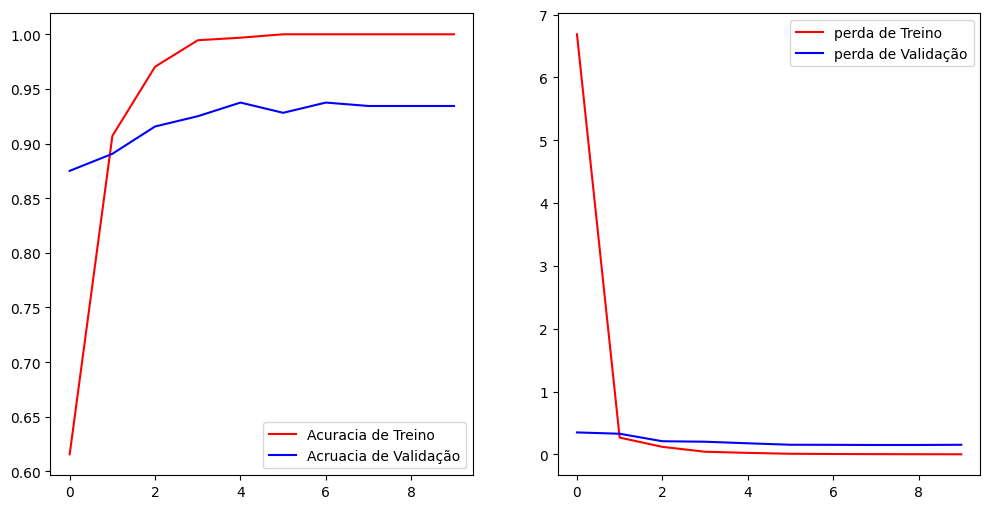

In [ ]:
# chama a função para ver o resultado com a redec convulacional
plota_resultado(history , epocas)

In [ ]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    66,064,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,197,774 (756.06 MB)

 Trainable params: 66,065,924 (252.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 132,131,850 (504.04 MB)

- Camadas convolucionais, ou camadas Conv, são um tipo específico de camada usada em redes neurais convolucionais (CNNs). Elas são projetadas para processar dados que têm uma estrutura em grade, como imagens, de uma maneira mais eficiente e eficaz do que as camadas densas tradicionais.

 - A camada de MaxPooling é uma técnica de pooling, que significa "agregação" ou "redução". Em termos simples, o MaxPooling reduz a resolução dos mapas de características, mantendo as informações mais importantes. Isso é feito através da aplicação de uma operação de pooling em regiões pequenas do mapa de características.

In [ ]:
# Cria uma classe de Callback personalizada herdando de tf.keras.callbacks.Callback
class myCallback(tf.keras.callbacks.Callback):
    # Função executada automaticamente ao final de cada época de treinamento
    def on_epoch_end(self, epoch, logs={}):
        # Verifica se a acurácia no conjunto de treino atingiu ou ultrapassou 96% (0.96)
        if(logs.get('accuracy') >= 0.96):
            print("\n Alcançamos 96% de acuracia. Parando o Treinamento")
            # Envia o sinal para o Keras interromper o treinamento antes de completar todas as épocas
            self.model.stop_training = True

# Instancia a classe criada para poder passá-la como parâmetro no modelo.fit()
callbacks = myCallback()


Aqui eu consigo limitar a porcentagem de acuracia que psso parar . no caso 0.96

In [ ]:
# Reinia e redefine o modelo aumentando a capacidade de extração de recursos (64 filtros convolucionais)
modelo = tf.keras.models.Sequential([
    # Define a camada de entrada (imagens 256x256x3)
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Normaliza a escala de cores dos pixels para [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),

    # Camada Convolucional: Agora com 64 filtros (o dobro do anterior) para extrair padrões mais complexos
    tf.keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu),

    # Camada de Max Pooling: Reduz o tamanho das características pela metade
    tf.keras.layers.MaxPooling2D(2,2),

    # Achata as matrizes em um vetor único 1D
    tf.keras.layers.Flatten(),

    # Camada oculta densa com 128 neurônios
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    # Camada de saída para as 4 classes com probabilidades
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

# Compila o novo modelo configurando otimizador, função de perda e métrica
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
# Treina o modelo com 64 filtros convolucionais usando o Callback de parada antecipada
epocas = 10

history = modelo.fit(
    treino,                     # Conjunto de dados de treinamento
    validation_data = validacao,# Conjunto de dados de validação
    epochs = epocas,            # Número máximo de épocas (10)
    callbacks = [callbacks]     # Ativa o callback para interromper o treino se atingir 96% de acurácia
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6641 - loss: 6.0802 - val_accuracy: 0.8875 - val_loss: 0.3384
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9438 - loss: 0.1627 - val_accuracy: 0.9125 - val_loss: 0.2461
Epoch 3/10
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9824 - loss: 0.0611
 Alcançamos 96% de acuracia. Parando o Treinamento
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9898 - loss: 0.0378 - val_accuracy: 0.9406 - val_loss: 0.1380


In [ ]:
# Reinia e redefine o modelo exatamente com a mesma arquitetura de 32 filtros convolucionais
modelo = tf.keras.models.Sequential([
    # Define a camada de entrada para imagens 256x256x3
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Normaliza a escala de cores dos pixels para [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),

    # Camada Convolucional com 32 filtros de 3x3
    tf.keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu),

    # Camada de Max Pooling
    tf.keras.layers.MaxPooling2D(2,2),

    # Achata as matrizes em um vetor único 1D
    tf.keras.layers.Flatten(),

    # Camada oculta densa com 128 neurônios
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    # Camada de saída para as 4 classes com probabilidades
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

In [ ]:
# Recompila o modelo com as mesmas configurações
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
import subprocess

def get_gpu_memory():
    try:
        # Executa o comando nvidia-smi para obter informações sobre a GPU
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, check=True)
        output = result.stdout

        # Procura por linhas que contenham informações de memória da GPU
        for line in output.split('\n'):
            if 'MiB' in line and 'GPU' in line:
                print(line)

        if 'No devices found' in output:
            print('Nenhuma GPU encontrada ou o comando nvidia-smi não está disponível.')

    except FileNotFoundError:
        print('O comando nvidia-smi não foi encontrado. Verifique se uma GPU está disponível e os drivers estão instalados.')
    except subprocess.CalledProcessError as e:
        print(f"Erro ao executar nvidia-smi: {e.stderr}")

print("Verificando a memória da GPU:")
get_gpu_memory()


Verificando a memória da GPU:


In [ ]:
# Aumenta o limite de épocas para 50 para um novo ciclo de treinamento
epocas = 50

# Recompila o modelo para garantir que está pronto para o treinamento
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Executa o treinamento por até 50 épocas sem o callback de parada antecipada
history = modelo.fit(
    treino,                     # Conjunto de dados de treinamento
    validation_data = validacao,# Conjunto de dados de validação
    epochs = epocas,            # Número máximo de épocas (50)
    callbacks = [callbacks]     # Ativa o callback para interromper o treino se atingir 96% de acurácia
)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6742 - loss: 2.7141 - val_accuracy: 0.8594 - val_loss: 0.3446
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9516 - loss: 0.1603 - val_accuracy: 0.9156 - val_loss: 0.1993
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9790 - loss: 0.0629
 Alcançamos 96% de acuracia. Parando o Treinamento
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9867 - loss: 0.0508 - val_accuracy: 0.9406 - val_loss: 0.1613


ValueError: x and y must have same first dimension, but have shapes (50,) and (3,)

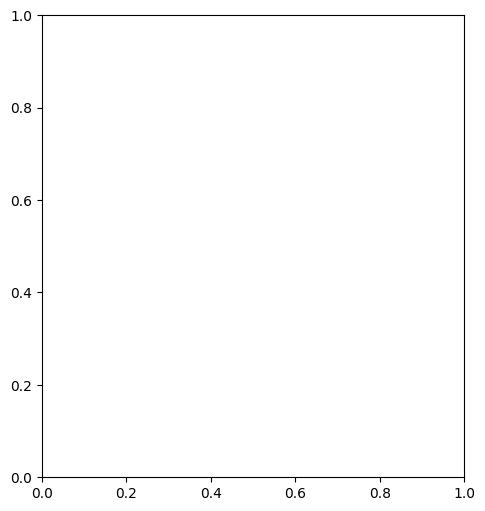

In [ ]:
plota_resultado(history, epocas)

In [ ]:
# Cria uma pipeline de Aumento de Dados (Data Augmentation) para gerar variações
# artificiais das imagens durante o treino e combater o overfitting
data_augmentation = tf.keras.Sequential([
    # Espelha as imagens aleatoriamente na horizontal (esquerda/direita)
    tf.keras.layers.RandomFlip('horizontal'),

    # Rotaciona as imagens aleatoriamente em até 5% (aproximadamente 18 graus)
    tf.keras.layers.RandomRotation(0.05),

    # Aplica zoom in/out aleatório de até 5%
    tf.keras.layers.RandomZoom(0.05)
])

In [ ]:
# Redefine a arquitetura do modelo incluindo a camada de Data Augmentation
modelo = tf.keras.models.Sequential([
    # Define o formato de entrada das imagens (256x256 pixels com 3 canais RGB)
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Aplica as transformações aleatórias (rotação, espelhamento, zoom) diretamente no pipeline
    data_augmentation,

    # Normaliza a escala de cores dos pixels para [0.0, 1.0]
    tf.keras.layers.Rescaling(1./255),

    # Camada Convolucional com 64 filtros de 3x3 para extração de padrões visuais
    tf.keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu),

    # Camada de Max Pooling para reduzir o tamanho espacial dos mapas de características
    tf.keras.layers.MaxPooling2D(2,2),

    # Achata as matrizes em um vetor único 1D
    tf.keras.layers.Flatten(),

    # Camada oculta densa com 128 neurônios
    tf.keras.layers.Dense(128, activation=tf.nn.relu),

    # Camada de saída para as 4 classes com probabilidades
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

# Compila o modelo atualizado com o otimizador Adam e a função de perda adequada
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
# Aumenta o limite de épocas para 50 para um novo ciclo de treinamento
epocas = 50

# Executa o treinamento por até 50 épocas sem o callback de parada antecipada
history = modelo.fit(
    treino,                     # Dados de treinamento
    validation_data = validacao,# Dados de validação
    epochs = epocas             # Número total de épocas
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.5703 - loss: 8.9371 - val_accuracy: 0.7500 - val_loss: 0.5740
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8305 - loss: 0.4637 - val_accuracy: 0.7188 - val_loss: 0.8163
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8914 - loss: 0.3159 - val_accuracy: 0.8625 - val_loss: 0.4371
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.9102 - loss: 0.2451 - val_accuracy: 0.7437 - val_loss: 0.8928
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9125 - loss: 0.2248 - val_accuracy: 0.6562 - val_loss: 1.3226
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9266 - loss: 0.1856 - val_accuracy: 0.7844 - val_loss: 0.7774
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9211 - loss: 0.2017 - val_accuracy: 0.8438 - val_loss: 0.4345
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9359 - loss: 0.1726 - val_accuracy: 0

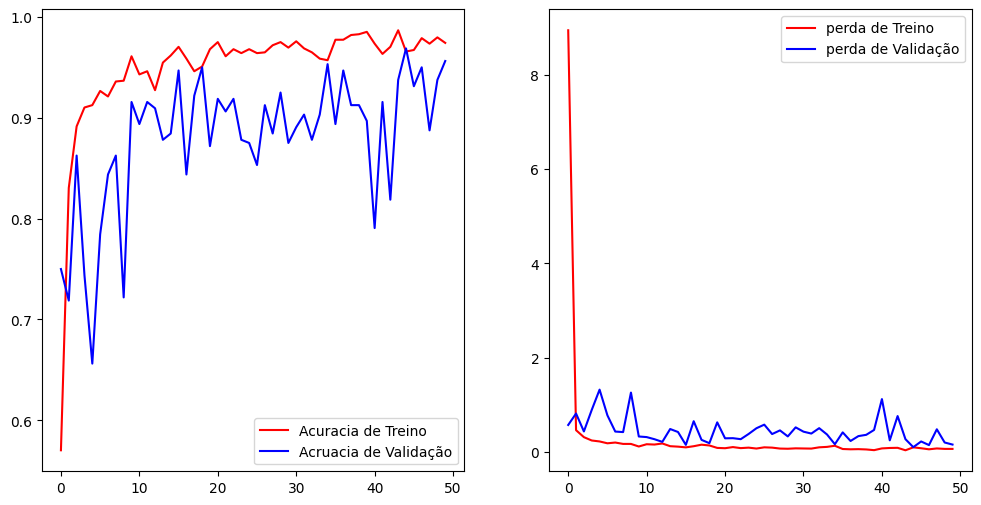

In [ ]:
plota_resultado(history, epocas)

In [ ]:
# Exemplo clássico de como salvar e carregar o modelo treinado na extensão .h5
modelo.save('meu_modelo_folhas.h5')

# Carrega o modelo completo de volta para a memória
# modelo_carregado = tf.keras.models.load_model('meu_modelo_folhas.h5')

# Usando um modelo treinado


In [ ]:
# Define a tupla com as dimensões de entrada da imagem: (altura, largura, canais de cor RGB)
# [NOTA]: Esta célula só é necessária se as células seguintes usarem a variável 'input_shape'
input_shape = (256, 256, 3)

In [ ]:
# Carrega a arquitetura pré-treinada InceptionV3 pré-configurada com os pesos da ImageNet
modelo_base = tf.keras.applications.InceptionV3(
    input_shape = input_shape, # Define a dimensão da imagem de entrada: (256, 256, 3)
    include_top = False,       # Remove a última camada de classificação padrão (1.000 classes do ImageNet)
    weights = 'imagenet'       # Importa os pesos pré-treinados no banco de dados ImageNet
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Congela todas as camadas e pesos do modelo base (InceptionV3)
# Garante que os filtros pré-treinados do ImageNet NÃO sejam alterados durante o treinamento
modelo_base.trainable = False

In [ ]:
# Exibe o resumo da arquitetura do modelo base (InceptionV3)
# [NOTA]: Útil para confirmar que as camadas foram congeladas corretamente
modelo_base.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 127, 127,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 125, 125,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 125, 125,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 62, 62,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 62, 62,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 60, 60,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Instancia a camada de reescalonamento para normalizar os pixels de [0, 255] para [0.0, 1.0]
rescale = tf.keras.layers.Rescaling(1./255)

# Aplica a normalização diretamente no pipeline de dados de treino (apenas na imagem 'x', mantendo o rótulo 'y')
treino = treino.map(lambda x, y: (rescale(x), y))

# Aplica a mesma normalização no pipeline de dados de validação
validacao = validacao.map(lambda x, y: (rescale(x), y))

In [ ]:
# Busca e extrai uma camada intermediária específica ('mixed7') da arquitetura InceptionV3
ultima_camada = modelo_base.get_layer('mixed7')

# Imprime o formato do mapa de características (tensor) na saída dessa camada
print('ultima_camada', ultima_camada.output.shape)

# Armazena a referência dessa saída para conectar às novas camadas personalizadas
ultima_saida = ultima_camada.output

# Imprime novamente para confirmação do formato do tensor de saída
print('ultima_saida: ', ultima_saida.shape)

ultima_camada (None, 14, 14, 768)
ultima_saida:  (None, 14, 14, 768)


In [ ]:
x = tf.keras.layers.GlobalAveragePooling2D()(ultima_saida)

# Adiciona uma camada oculta Densa com 1.024 neurônios e ativação ReLU para aprender padrões complexos
x = tf.keras.layers.Dense(1024, activation='relu')(x)

# Aplica Dropout de 20%: desliga aleatoriamente 20% dos neurônios a cada passo para evitar overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Camada final de saída com 4 neurônios (uma para cada classe) e ativação Softmax para gerar probabilidades
x = tf.keras.layers.Dense(4, activation='softmax')(x)

# Constrói o modelo final conectando a entrada original do InceptionV3 à nova saída 'x' (Functional API)
modelo = tf.keras.Model(inputs=modelo_base.input, outputs=x)

In [ ]:
modelo.summary()

In [ ]:
# Compila o modelo unificado (InceptionV3 + novas camadas de classificação)
modelo.compile(
    optimizer = tf.keras.optimizers.Adam(),        # Otimizador Adam para ajustar apenas os pesos das novas camadas
    loss = 'sparse_categorical_crossentropy',       # Função de perda para classificação multiclasse com rótulos inteiros
    metrics = ['accuracy']                          # Métrica para monitorar a porcentagem de acertos
)

In [ ]:
epocas = 20

history = modelo.fit(
    treino,
    validation_data = validacao,
    epochs = epocas
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - accuracy: 0.8555 - loss: 0.5934 - val_accuracy: 0.9812 - val_loss: 0.1726
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9766 - loss: 0.1295 - val_accuracy: 0.9750 - val_loss: 0.0918
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9836 - loss: 0.0734 - val_accuracy: 0.9812 - val_loss: 0.0547
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9750 - loss: 0.0736 - val_accuracy: 0.9906 - val_loss: 0.0369
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9883 - loss: 0.0446 - val_accuracy: 0.9875 - val_loss: 0.0320
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 0.9812 - val_loss: 0.0579
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9875 - loss: 0.0369 - val_accuracy: 0.9812 - val_loss: 0.0585
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9672 - loss: 0.0711 - val_accuracy: 0.9844 -

In [ ]:
# 1. Salva o modelo COMPLETO (Arquitetura + Pesos + Estado do Otimizador) em formato HDF5
modelo.save('modelo_transfericia_de_aprendizado.h5')

In [ ]:
# 2. Salva o modelo completo, mas REMOVE o otimizador (deixa o arquivo mais leve, ideal para produção/inferência)
modelo.save('modelo_final_de_aprendizado.h5', include_optimizer=False)

In [ ]:
# 3. Salva APENAS os pesos/parâmetros ajustados do modelo (requer recriar a arquitetura via código para carregar)
modelo.save_weights('pesos.weights.h5')

# CONVERSÃO E QUANTIZAÇÃO PARA TENSORFLOW LITE (MÓVEL / EMBARCADO)





In [ ]:
# Prepara o conversor do TensorFlow Lite a partir do modelo Keras
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)


In [ ]:
# Habilita otimizações padrão de conversão (redução de tamanho e ganho de velocidade)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Define a quantização para Float16 (reduz o tamanho do modelo pela metade com perda insignificante de precisão)
converter.target_spec.supported_types = [tf.float16]

# Executa a conversão e quantização do modelo
modelo_tflite_quantizado = converter.convert()

# Salva o arquivo final binário '.tflite' no disco para uso em aplicativos Android, iOS ou Raspberry Pi
with open('modelo_quantizado.tflite', 'wb') as f:

  f.write(modelo_tflite_quantizado)

Saved artifact at '/tmp/tmp30kaaveu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_38')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133272457025808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413653200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413653968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413660880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413657040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413658192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413653776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413656080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413656656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133274413653008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13327441364